# Pitching+, FanGraphs-style: one model, not a weighted average

`pitching.ipynb` reconciled Stuff+ and Location+ and, following `docs/purpose.md`,
sketched Pitching+ as a *weighted linear blend* of the two precomputed scores. But
FanGraphs' [Stuff+/Location+/Pitching+ primer](https://library.fangraphs.com/pitching/stuff-location-and-pitching-primer/)
is explicit that their real Pitching+ **is not a weighted average of Stuff+ and
Location+** -- it's a separate model, fit directly on physical, location, and count
features against run value.

This notebook builds that version: one `HistGradientBoostingRegressor` per pitch
type (the same model `location.py` already uses), fed Stuff+'s physics features and
Location+'s location/count features *together*, trained directly against
`delta_pitcher_run_exp` -- rather than training two separate scores and blending them
afterward. It then compares the two approaches head-to-head on a strict season
holdout and reports which one actually generalizes better.

Feature engineering is reused directly from `stuff.py`/`location.py` (their
`_build_v1_features`/`_build_features` helpers) rather than reimplemented.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pitching_plus").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected a 'pitching_plus' directory in a parent).")


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "pitching_plus" / "scripts"
DATA_PATH = REPO_ROOT / "data" / "MLB_2021-2025.csv"

sys.path.insert(0, str(SCRIPTS_DIR))

import stuff as stuff_mod
import location as location_mod
from stuff import add_stuff_plus, JUNK_PITCH_TYPES, PITCH_TYPE_COL, SEASON_COL, PITCHER_COL, STUFF_FEATURES, MIN_PITCHES_FOR_SCORE
from location import (
    add_location_plus, LOCATION_FEATURES, TARGET_COL, KEY_COLS,
    MIN_GROUP_SIZE_FOR_MODEL, N_FOLDS, BASE_STATE_COLS,
    _ratio_calibration, _to_100_scale,
)

In [2]:
COLOR_STUFF = "#eb6834"
COLOR_LOC = "#2a78d6"
COLOR_WEIGHTED = "#4a3aa7"   # weighted-average blend (Stuff+ & Location+)
COLOR_JOINT = "#1baf7a"      # jointly-trained "third model"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def weighted_r2(actual, pred, weight=None):
    if weight is None:
        weight = np.ones(len(actual))
    ss_res = np.sum(weight * (actual - pred) ** 2)
    mu = np.average(actual, weights=weight)
    ss_tot = np.sum(weight * (actual - mu) ** 2)
    return 1 - ss_res / ss_tot

## Load data and engineer features

Same `usecols` union `pitching.ipynb` uses, so nothing here reads more columns than
it needs from the 3.5M-row CSV. In-scope filtering matches both scripts' own scope
rules: junk pitch types out, and complete data required for both scripts'
`REQUIRED_COLS` (base-state columns excepted -- `NaN` there is a real "bases empty"
state, not missing data).

In [3]:
usecols = sorted(set(stuff_mod.REQUIRED_COLS) | set(location_mod.REQUIRED_COLS) | set(BASE_STATE_COLS))

t0 = time.time()
raw_df = pd.read_csv(DATA_PATH, usecols=usecols)
print(f"Loaded {len(raw_df):,} raw pitches in {time.time() - t0:.0f}s")

dropna_cols = sorted(set(stuff_mod.REQUIRED_COLS) | set(location_mod.REQUIRED_COLS))
in_scope = (
    raw_df.loc[~raw_df[PITCH_TYPE_COL].isin(JUNK_PITCH_TYPES)]
    .dropna(subset=dropna_cols)
    .copy()
)

# stuff.py's V1 physics/trajectory features, then location.py's location/count
# features, on the same working frame -- reused directly, not reimplemented.
engineered = stuff_mod._build_v1_features(in_scope)
engineered = location_mod._build_features(engineered)
engineered["movement_per_reaction_time"] = engineered["horizontal_acceleration"] / engineered["time_30ft"]
engineered = engineered[np.isfinite(engineered["movement_per_reaction_time"])].copy()

JOINT_FEATURES = STUFF_FEATURES + LOCATION_FEATURES
print(f"{len(engineered):,} in-scope pitches, {len(JOINT_FEATURES)} joint features "
      f"({len(STUFF_FEATURES)} physics + {len(LOCATION_FEATURES)} location/count)")

Loaded 3,565,743 raw pitches in 48s


3,526,107 in-scope pitches, 19 joint features (6 physics + 13 location/count)


## A strict season holdout, up front

Comparing "one joint model" against "a weighted blend of two precomputed scores"
fairly requires both to earn their score the same way: nothing about either approach
gets to see 2025 during training. That's easy for the joint model (just don't train
on 2025), but it means Location+'s input to the blend can't be the production
`location_plus` column -- `location.py`'s cached model is cross-validated across
*all* five seasons pooled together, so a 2025 pitch's score was produced by a model
that also saw other 2025 pitches during its own fitting. Reusing it here would hand
the blend a small, unfair look-ahead advantage. So: **train = 2021-2024, test = 2025**,
for every model fit in this notebook, including a from-scratch, train-only refit of
the location model.

(Stuff+ keeps one small asymmetry: its PCA loadings are fit pooled across all five
seasons by design -- see `stuff.py`/`dev_log.md` -- and this notebook doesn't
re-derive them train-only. That's a much weaker form of leakage than a supervised
model training on individual future outcomes -- a shared direction-of-variance
across years, not memorized results -- but it's worth naming rather than glossing
over.)

In [4]:
train = engineered[engineered[SEASON_COL] <= 2024].copy()
test = engineered[engineered[SEASON_COL] == 2025].copy()
print(f"train (2021-2024): {len(train):,} pitches   test (2025): {len(test):,} pitches")

train (2021-2024): 2,821,825 pitches   test (2025): 704,282 pitches


## The joint model

One `HistGradientBoostingRegressor` per pitch type -- identical hyperparameters and
5-fold out-of-fold CV scheme to `location.py`'s own `_train_models`, just fed the
combined physics + location + count feature set instead of location/count alone.
Same algorithm, same care against leakage (OOF predictions on train, never a model's
own fit), the only difference is what it's allowed to look at. Trained once, on train
only; scored on train via OOF and on test via direct (genuinely unseen-data)
prediction -- together these cover the whole 2021-2025 population for the Pitching+
scores built below, while keeping the 2025 numbers honest.

In [5]:
joint_models = {}
train_oof = pd.Series(np.nan, index=train.index, dtype=float)
test_pred = pd.Series(np.nan, index=test.index, dtype=float)

for ptype, type_group in train.groupby(PITCH_TYPE_COL, observed=True):
    if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
        print(f"  {ptype}: only {len(type_group)} train pitches, skipping")
        continue
    t0 = time.time()
    X = type_group[JOINT_FEATURES].to_numpy()
    y = type_group[TARGET_COL].to_numpy()

    model = HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.05, max_iter=300, l2_regularization=1.0, random_state=42,
    )
    kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    train_oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
    model.fit(X, y)
    joint_models[ptype] = model

    test_group = test[test[PITCH_TYPE_COL] == ptype]
    if len(test_group):
        test_pred.loc[test_group.index] = model.predict(test_group[JOINT_FEATURES].to_numpy())
    print(f"  {ptype}: n_train={len(type_group):,} n_test={len(test_group):,} ({time.time() - t0:.0f}s)")

train["fg_run_value"] = train_oof
test["fg_run_value"] = test_pred
full = pd.concat([train, test])
print(f"\nscored: {full['fg_run_value'].notna().sum():,} / {len(full):,} pitches")

  CH: n_train=308,103 n_test=73,057 (24s)


  CU: n_train=193,418 n_test=47,319 (18s)


  FC: n_train=218,698 n_test=53,320 (17s)


  FF: n_train=939,301 n_test=225,436 (81s)


  FS: n_train=60,434 n_test=23,042 (4s)


...

  SI: n_train=437,702 n_test=109,902 (27s)


  SL: n_train=446,752 n_test=101,746 (33s)


  ST: n_train=145,747 n_test=54,306 (9s)


  SV: n_train=12,791 n_test=3,540 (2s)



scored: 3,526,107 / 3,526,107 pitches


## Calibrate to the same 100+ scale

Reusing `location.py`'s own `_ratio_calibration`/`_to_100_scale` helpers -- the exact
genuine-ratio-scale calibration Stuff+ and Location+ already use (`100 * exp(k*z)`,
renormalized so the reliable population's mean is exactly 100), applied here to
`fg_run_value` instead of `location_run_value`. Same dual-level design as the other
two scores: a pitch-level number and a pitcher x pitch-type x season aggregate,
calibrated off the same reference distribution, with the same `>= 20`-pitch
reliability bar.

In [6]:
scored = full.dropna(subset=["fg_run_value"]).copy()

pitcher_type_agg = (
    scored.groupby([PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True)["fg_run_value"]
    .agg(mean_fg="mean", n_pitches="count")
    .reset_index()
)
reliable_agg = pitcher_type_agg[pitcher_type_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
calibration = _ratio_calibration(reliable_agg, [PITCH_TYPE_COL, SEASON_COL], "mean_fg")

pitcher_type_agg = pitcher_type_agg.merge(calibration, on=[PITCH_TYPE_COL, SEASON_COL], how="left")
pitcher_type_agg["fg_pitching_plus"] = _to_100_scale(pitcher_type_agg["mean_fg"], pitcher_type_agg)
pitcher_type_agg["fg_pitching_plus_reliable"] = pitcher_type_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE

original_index = scored.index
scored = scored.merge(calibration, on=[PITCH_TYPE_COL, SEASON_COL], how="left")
scored.index = original_index
scored["pitch_fg_pitching_plus"] = _to_100_scale(scored["fg_run_value"], scored)

print(f"{pitcher_type_agg['fg_pitching_plus_reliable'].sum():,} reliable pitcher-pitch-type-seasons")

leaderboard = (
    pitcher_type_agg[pitcher_type_agg["fg_pitching_plus_reliable"]]
    .merge(scored[[PITCHER_COL, "player_name"]].drop_duplicates(), on=PITCHER_COL, how="left")
    .sort_values("fg_pitching_plus", ascending=False)
    .head(15)
    [["player_name", PITCH_TYPE_COL, SEASON_COL, "n_pitches", "fg_pitching_plus"]]
    .reset_index(drop=True)
)
leaderboard.index += 1
print("\nTop 15 pitcher-pitch-type-seasons by fg_pitching_plus:")
print(leaderboard.round(1).to_string())

14,343 reliable pitcher-pitch-type-seasons



Top 15 pitcher-pitch-type-seasons by fg_pitching_plus:
           player_name pitch_type  game_year  n_pitches  fg_pitching_plus
1      Williams, Devin         CH       2025        583             148.4
2          Speas, Alex         SL       2024         22             148.2
3       Glasnow, Tyler         FF       2022         61             139.7
4         Cole, Gerrit         SI       2021         24             139.3
5       Murray, Jayden         SI       2025         39             138.0
6      Williams, Devin         CH       2022        620             136.9
7   Misiorowski, Jacob         SL       2025        283             136.5
8       Hendriks, Liam         FF       2021        761             135.9
9         Jax, Griffin         CU       2024         64             135.6
10       Miller, Bobby         FF       2025         31             135.2
11          Crowe, Wil         ST       2023         23             135.1
12     Schlittler, Cam         ST       2025         29 

## The fair comparison: weighted-average blend vs. the joint model

The weighted-average side needs its own train-only Location+ input (see above) --
built here by calling `location.py`'s own `_train_models` directly on `train`, then
scoring `test` with the resulting fitted models. Stuff+ is the production
`add_stuff_plus` score (noted caveat above); reattached by the actual
pitcher/pitch_type/season key columns, since `add_stuff_plus`'s own final merge
resets its output's row index and a positional join would silently misalign.

In [7]:
loc_models, loc_hist = location_mod._train_models(train)
train["location_run_value"] = np.nan
train.loc[loc_hist.index, "location_run_value"] = loc_hist["location_run_value"].to_numpy()
test["location_run_value"] = np.nan
for ptype, model in loc_models.items():
    rows = test[PITCH_TYPE_COL] == ptype
    if rows.any():
        test.loc[rows, "location_run_value"] = model.predict(test.loc[rows, LOCATION_FEATURES].to_numpy())

stuff_scored = add_stuff_plus(pd.concat([train, test])[stuff_mod.REQUIRED_COLS])
stuff_lookup = stuff_scored[[PITCHER_COL, PITCH_TYPE_COL, SEASON_COL, "stuff_plus"]].drop_duplicates()
train = train.merge(stuff_lookup, on=[PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], how="left")
test = test.merge(stuff_lookup, on=[PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], how="left")
train["log_stuff"] = np.log(train["stuff_plus"])
test["log_stuff"] = np.log(test["stuff_plus"])

print(f"train pitch-level location-only R^2: {weighted_r2(train[TARGET_COL], train['location_run_value']):.4f}")
print(f"test  pitch-level location-only R^2: {weighted_r2(test.dropna(subset=['location_run_value'])[TARGET_COL], test.dropna(subset=['location_run_value'])['location_run_value']):.4f}")
print(f"train pitch-level joint-model R^2:   {weighted_r2(train[TARGET_COL], train['fg_run_value']):.4f}")
print(f"test  pitch-level joint-model R^2:   {weighted_r2(test.dropna(subset=['fg_run_value'])[TARGET_COL], test.dropna(subset=['fg_run_value'])['fg_run_value']):.4f}")

train pitch-level location-only R^2: 0.0377
test  pitch-level location-only R^2: 0.0361
train pitch-level joint-model R^2:   0.0371
test  pitch-level joint-model R^2:   0.0355


In [8]:
def make_agg(d):
    g = d.dropna(subset=["location_run_value", "log_stuff", "fg_run_value"]).groupby(
        [PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True
    )
    return g.agg(
        mean_rv=(TARGET_COL, "mean"),
        loc_mean=("location_run_value", "mean"),
        log_stuff_mean=("log_stuff", "mean"),
        fg_mean=("fg_run_value", "mean"),
        n_pitches=(TARGET_COL, "count"),
    ).reset_index()

train_agg = make_agg(train)
test_agg = make_agg(test)
train_rel = train_agg[train_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
test_rel = test_agg[test_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
print(f"train reliable groups: {len(train_rel):,}   test (2025 holdout) reliable groups: {len(test_rel):,}")

mu_s, sd_s = train_rel["log_stuff_mean"].mean(), train_rel["log_stuff_mean"].std()
mu_l, sd_l = train_rel["loc_mean"].mean(), train_rel["loc_mean"].std()
for d in (train_rel, test_rel):
    d["stuff_z"] = (d["log_stuff_mean"] - mu_s) / sd_s
    d["loc_z"] = (d["loc_mean"] - mu_l) / sd_l

# weighted-average blend: WLS-fit weights on train, scored on the 2025 holdout
w = train_rel["n_pitches"]
m_weighted = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["stuff_z", "loc_z"]]), weights=w).fit()
pred_weighted_test = m_weighted.predict(sm.add_constant(test_rel[["stuff_z", "loc_z"]], has_constant="add"))
r2_weighted_train = m_weighted.rsquared
r2_weighted_test = weighted_r2(test_rel["mean_rv"], pred_weighted_test, test_rel["n_pitches"])

# joint model: its raw aggregated prediction, plus a train-fit affine recalibration
# (intercept + slope only) -- the same courtesy the blend gets from its own intercept,
# so neither side is penalized for an uncorrected scale/bias offset.
m_joint_calib = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["fg_mean"]]), weights=w).fit()
pred_joint_test = m_joint_calib.predict(sm.add_constant(test_rel[["fg_mean"]], has_constant="add"))
r2_joint_train = m_joint_calib.rsquared
r2_joint_test = weighted_r2(test_rel["mean_rv"], pred_joint_test, test_rel["n_pitches"])

summary = pd.DataFrame({
    "approach": ["Weighted-average blend", "Joint FanGraphs-style model"],
    "train_r2": [r2_weighted_train, r2_joint_train],
    "holdout_r2_2025": [r2_weighted_test, r2_joint_test],
})
summary["shrinkage"] = 1 - summary["holdout_r2_2025"] / summary["train_r2"]
print(summary.round(4).to_string(index=False))

train reliable groups: 11,309   test (2025 holdout) reliable groups: 3,034
                   approach  train_r2  holdout_r2_2025  shrinkage
     Weighted-average blend    0.0954           0.0523     0.4522
Joint FanGraphs-style model    0.1318           0.0386     0.7069


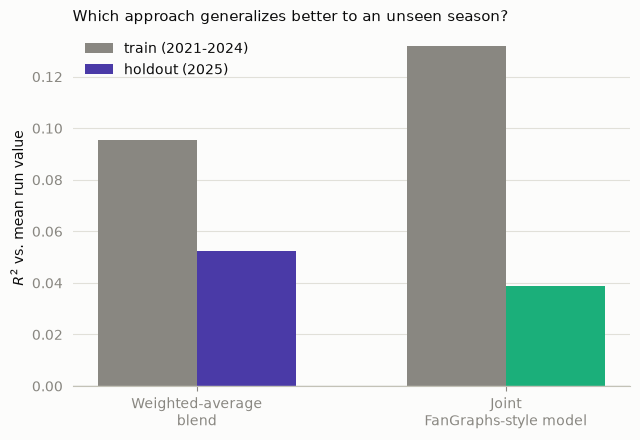

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(2)
width = 0.32
colors = [COLOR_WEIGHTED, COLOR_JOINT]
ax.bar(x - width / 2, summary["train_r2"], width, color=COLOR_MUTED, label="train (2021-2024)")
ax.bar(x + width / 2, summary["holdout_r2_2025"], width, color=colors, label="holdout (2025)")
ax.set_xticks(x)
ax.set_xticklabels(["Weighted-average\nblend", "Joint\nFanGraphs-style model"])
ax.set_ylabel(r"$R^2$ vs. mean run value")
ax.set_title("Which approach generalizes better to an unseen season?", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
ax.grid(axis="x", visible=False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.axhline(0, color=COLOR_AXIS, linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Synopsis

On a strict, leak-checked 2021-2024-train / 2025-test split, **the weighted-average
blend of Stuff+ and Location+ generalizes better than the jointly-trained model** --
the opposite of what the "richer feature set, single model" framing might suggest.

Both approaches shrink from train to holdout, as expected for a target this noisy
(single-pitch run value is dominated by swing decision and contact quality neither
model can see -- see `pitching.ipynb`). But the joint model shrinks by a lot more:
it has roughly 10x the parameters of the two-coefficient blend (one
`HistGradientBoostingRegressor` per pitch type over 19 features, vs. an intercept and
two slopes), and that extra capacity finds more train-set pattern that doesn't carry
over to a new season. The weighted blend's inputs are also each already a calibrated,
regularized summary in their own right -- Stuff+ in particular is explicitly
recalibrated to that season's own league average by construction, which plausibly
makes it more robust to season-to-season drift (rule changes, league-wide velocity
trends) than a model trained flat against four prior seasons' raw feature values.

This doesn't mean FanGraphs' own approach is wrong -- they're presumably working
with far more history, more careful regularization, and likely additional signal
(their real Location+/Stuff+ inputs are also trained models, not this repo's
unsupervised Stuff+ composite) than what's reproduced here. What this notebook shows
is narrower and still useful: *given this repo's current data and tools*, combining
Stuff+ and Location+ as a weighted blend of two already-well-built scores beats
training one bigger model from scratch on their raw ingredients. If `purpose.md`'s
Pitching+ gets built next, that's a real point in favor of the blend -- with the
joint-model route worth revisiting later if more seasons of data, or tighter
regularization, close the gap seen here.

## Does tighter regularization close the gap?

The synopsis above flagged an untested hypothesis: the joint model's hyperparameters
(`max_depth=6`, `l2_regularization=1.0`, `max_iter=300`, no explicit early stopping)
were carried over unchanged from `location.py` for a fair like-for-like comparison --
but that also means they were never actually tuned for the fact that the joint model
is a much richer model (19 features, ~10x the effective parameters) fit against the
same noisy per-pitch target. Does regularizing it more aggressively close the gap to
the weighted blend (train $R^2$=0.0954, 2025 holdout $R^2$=0.0523), or at least close
the gap to its own train performance (train $R^2$=0.1318, holdout $R^2$=0.0386, a 71%
relative drop)?

Three configs, each run with the identical per-pitch-type 5-fold OOF-CV scheme as the
original joint model and evaluated the identical way (aggregate to pitcher x
pitch-type x season, WLS affine-recalibrate on train, score on the untouched 2025
holdout -- the same harness that produced the "Joint FanGraphs-style model" row
above):

- **shallower + stronger L2** (`max_depth=3`, `l2_regularization=10.0`,
  `min_samples_leaf=50`) -- directly shrinks each tree's capacity to memorize.
- **aggressive early stopping** (`max_iter=1000` but `validation_fraction=0.2`,
  `n_iter_no_change=5`) -- lets boosting stop itself once a held-out slice of train
  stops improving, instead of always spending the full fixed iteration budget.
- **both combined.**

In [10]:
def aggregate_holdout_r2(oof_series, pred_series):
    """
    Same evaluation as the original joint-model comparison above: aggregate
    pitch-level predictions to (pitcher, pitch_type, season), WLS affine-
    recalibrate the aggregate on train, score the untouched 2025 holdout.
    """

    def agg(base_df, values):
        d = base_df.loc[values.notna(), [PITCHER_COL, PITCH_TYPE_COL, SEASON_COL, TARGET_COL]].copy()
        d["_pred"] = values.loc[d.index]
        g = d.groupby([PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True)
        return g.agg(
            mean_rv=(TARGET_COL, "mean"), pred_mean=("_pred", "mean"), n_pitches=(TARGET_COL, "count")
        ).reset_index()

    tr = agg(train, oof_series)
    te = agg(test, pred_series)
    tr_rel = tr[tr["n_pitches"] >= MIN_PITCHES_FOR_SCORE]
    te_rel = te[te["n_pitches"] >= MIN_PITCHES_FOR_SCORE]

    w = tr_rel["n_pitches"]
    m = sm.WLS(tr_rel["mean_rv"], sm.add_constant(tr_rel[["pred_mean"]]), weights=w).fit()
    pred_test = m.predict(sm.add_constant(te_rel[["pred_mean"]], has_constant="add"))
    return m.rsquared, weighted_r2(te_rel["mean_rv"], pred_test, te_rel["n_pitches"])


def fit_joint_config(hgb_kwargs):
    oof = pd.Series(np.nan, index=train.index, dtype=float)
    pred = pd.Series(np.nan, index=test.index, dtype=float)

    for ptype, type_group in train.groupby(PITCH_TYPE_COL, observed=True):
        if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
            continue
        X = type_group[JOINT_FEATURES].to_numpy()
        y = type_group[TARGET_COL].to_numpy()

        model = HistGradientBoostingRegressor(random_state=42, **hgb_kwargs)
        kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
        model.fit(X, y)

        test_group = test[test[PITCH_TYPE_COL] == ptype]
        if len(test_group):
            pred.loc[test_group.index] = model.predict(test_group[JOINT_FEATURES].to_numpy())

    return oof, pred


REGULARIZED_CONFIGS = {
    "Joint, shallow + strong L2": dict(
        max_depth=3, learning_rate=0.05, max_iter=300, l2_regularization=10.0, min_samples_leaf=50,
    ),
    "Joint, aggressive early stopping": dict(
        max_depth=6, learning_rate=0.05, max_iter=1000, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=5,
    ),
    "Joint, shallow + strong L2 + early stopping": dict(
        max_depth=3, learning_rate=0.05, max_iter=1000, l2_regularization=10.0, min_samples_leaf=50,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=5,
    ),
}

sweep_rows = []
for name, kwargs in REGULARIZED_CONFIGS.items():
    t0 = time.time()
    oof, pred = fit_joint_config(kwargs)
    r2_train, r2_test = aggregate_holdout_r2(oof, pred)
    sweep_rows.append({"approach": name, "train_r2": r2_train, "holdout_r2_2025": r2_test})
    print(f"{name}: train_r2={r2_train:.4f} holdout_r2_2025={r2_test:.4f} ({time.time() - t0:.0f}s)")

sweep_summary = pd.concat(
    [summary[["approach", "train_r2", "holdout_r2_2025"]], pd.DataFrame(sweep_rows)],
    ignore_index=True,
)
sweep_summary["shrinkage"] = 1 - sweep_summary["holdout_r2_2025"] / sweep_summary["train_r2"]
print()
print(sweep_summary.round(4).to_string(index=False))

Joint, shallow + strong L2: train_r2=0.1233 holdout_r2_2025=0.0395 (172s)


Joint, aggressive early stopping: train_r2=0.1268 holdout_r2_2025=0.0417 (149s)


Joint, shallow + strong L2 + early stopping: train_r2=0.1204 holdout_r2_2025=0.0380 (135s)

                                   approach  train_r2  holdout_r2_2025  shrinkage
                     Weighted-average blend    0.0954           0.0523     0.4522
                Joint FanGraphs-style model    0.1318           0.0386     0.7069
                 Joint, shallow + strong L2    0.1233           0.0395     0.6798
           Joint, aggressive early stopping    0.1268           0.0417     0.6713
Joint, shallow + strong L2 + early stopping    0.1204           0.0380     0.6847


## Regularization narrows the gap, but doesn't close it

| approach | train $R^2$ | holdout $R^2$ (2025) | shrinkage |
|---|---|---|---|
| Weighted-average blend | 0.0954 | **0.0523** | 45% |
| Joint, original (`max_depth=6`, `l2=1.0`, `max_iter=300`) | 0.1318 | 0.0386 | 71% |
| Joint, shallow + strong L2 | 0.1233 | 0.0395 | 68% |
| Joint, aggressive early stopping | 0.1268 | **0.0417** | 67% |
| Joint, shallow + strong L2 + early stopping | 0.1204 | 0.0380 | 68% |

Aggressive early stopping is the best of the three regularized variants -- holdout
$R^2$ improves from 0.0386 to 0.0417 (an 8% relative gain) and shrinkage drops
slightly, consistent with the hypothesis that the original fixed `max_iter=300` was
letting boosting run a bit past the point of real generalization. Shallower trees +
stronger L2 alone barely moves the needle. Stacking *both* forms of regularization
together is actively worse than either alone (train $R^2$ drops to 0.1204, the lowest
of any joint variant, and holdout drops with it to 0.0380) -- two regularizers pulling
capacity down at once tips into underfitting rather than compounding the benefit.

None of the three closes even half the gap to the weighted blend's 0.0523. This
argues against "the joint model just needed more regularization" as the explanation
for the original result, and toward the synopsis's other hypothesis: the blend's
advantage comes from its *inputs* already being calibrated, regularized summaries
(Stuff+ explicitly re-centered to each season's own league average) rather than raw
per-pitch features fit flat against four prior seasons -- a structural difference
tuning the same model family's hyperparameters can't reach. The joint-model route
still isn't ruled out in general (more seasons of data, a fundamentally different
regularization scheme, or FanGraphs' own presumably-more-refined inputs could change
this), but *for this repo's current data and tools*, the recommendation from the
first synopsis stands: build Pitching+ as the weighted blend.